# Bayesian Network Structure Learning — POC Experiment

Compares **Hill Climbing** (pgmpy) against **NOTEARS** (gcastle) in two feature regimes:
- Low-dimensional: 10 features, 1000 samples
- High-dimensional: 100 features, 1000 samples

Each dataset is split 90/10 into train/test. We measure wall-clock time for structure learning.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from data import *
from reporting import graph_metrics
from training import *


SEED = 42


/home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.
  from .StructureScore import (
2026-07-01 21:56:19,137 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/backend/__init__.py[line:36] - INFO: You can use `os.environ['CASTLE_BACKEND'] = backend` to set the backend(`pytorch` or `mindspore`).
2026-07-01 21:56:19,156 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/__init__.py[line:36] - INFO: You are using ``pytorch`` as the backend.


In [2]:
sachs_df, sachs_dag  = load_sachs()
print(f"Sachs: {sachs_df.shape[0]} samples, {sachs_df.shape[1]} nodes, {len(sachs_dag.edges())} true edges")

sachs_notears_result = train_notears(sachs_df, lambda1=0.1, w_threshold=0.5)
sachs_notears_metrics = graph_metrics(sachs_dag.edges, sachs_notears_result.edges)
sachs_daggnn_result = train_daggnn(sachs_df, mlp_dimension=32, epochs=100, lr=0.03, graph_threshold=0.1)
sachs_daggnn_metrics = graph_metrics(sachs_dag.edges, sachs_daggnn_result.edges)

sachs_hc_result = train_hill_climbing(sachs_df)
sachs_hc_metrics = graph_metrics(sachs_dag.edges, sachs_hc_result.edges)
sachs_pc_result = train_pc(sachs_df, ci_test="pearsonr", significance_level=0.001, max_cond_vars=None)
sachs_pc_metrics = graph_metrics(sachs_dag.edges, sachs_pc_result.edges)
sachs_fges_result = train_fges(sachs_df, method="r2")
sachs_fges_metrics = graph_metrics(sachs_dag.edges, sachs_fges_result.edges)


2026-07-01 21:56:19,191 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:195] - INFO: [start]: n=11672, d=11, iter_=100, h_=1e-08, rho_=10000000000000000


Sachs: 11672 samples, 11 nodes, 20 true edges


2026-07-01 21:56:20,887 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 0] h=2.495e+00, loss=543643.397, rho=1.0e+00
2026-07-01 21:56:20,929 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=2.493e+00, loss=259291.045, rho=1.0e+00
2026-07-01 21:56:21,043 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=2.464e+00, loss=259319.053, rho=1.0e+01
2026-07-01 21:56:21,674 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=2.251e+00, loss=259599.133, rho=1.0e+02
2026-07-01 21:56:22,850 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradie

In [13]:
CANCER_SAMPLES = 1000
cancer_df, cancer_dag  = load_cancer(CANCER_SAMPLES, seed=SEED)
print(f"cancer: {cancer_df.shape[0]} samples, {cancer_df.shape[1]} nodes, {len(cancer_dag.edges())} true edges")

cancer_notears_result = train_notears(cancer_df, lambda1=0.01, w_threshold=0.0)
cancer_notears_metrics = graph_metrics(cancer_dag.edges, cancer_notears_result.edges)
cancer_daggnn_result = train_daggnn(cancer_df, mlp_dimension=32, epochs=100, lr=0.003, graph_threshold=0.1)
cancer_daggnn_metrics = graph_metrics(cancer_dag.edges, cancer_daggnn_result.edges)

cancer_hc_result = train_hill_climbing(cancer_df)
cancer_hc_metrics = graph_metrics(cancer_dag.edges, cancer_hc_result.edges)
cancer_pc_result = train_pc(cancer_df, ci_test="pearsonr", significance_level=0.005, max_cond_vars=None)
cancer_pc_metrics = graph_metrics(cancer_dag.edges, cancer_pc_result.edges)
cancer_fges_result = train_fges(cancer_df, method="scatter")
cancer_fges_metrics = graph_metrics(cancer_dag.edges, cancer_fges_result.edges)


Generating for node: Dyspnoea: 100%|██████████| 5/5 [00:00<00:00, 723.28it/s]
2026-07-01 23:08:02,552 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:195] - INFO: [start]: n=1000, d=5, iter_=100, h_=1e-08, rho_=10000000000000000
2026-07-01 23:08:02,560 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 0] h=8.105e-07, loss=0.347, rho=1.0e+00
2026-07-01 23:08:02,564 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=8.105e-07, loss=0.347, rho=1.0e+00
2026-07-01 23:08:02,567 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=8.105e-07, loss=0.347, rho=1.0e+01
2026-07-01 23:08:02,569 - /home/danie/codice/uni/b

cancer: 1000 samples, 5 nodes, 4 true edges


2026-07-01 23:08:07,016 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:253] - INFO: Iter: 0, epoch: 99, h_new: 0.0011701504513990102
2026-07-01 23:08:11,386 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:253] - INFO: Iter: 1, epoch: 99, h_new: 0.0011701504513990102
2026-07-01 23:08:24,430 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:253] - INFO: Iter: 2, epoch: 99, h_new: 0.00014469971200536946
2026-07-01 23:08:33,114 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:253] - INFO: Iter: 3, epoch: 99, h_new: 2.9209005552033318e-05
2026-07-01 23:08:41,709 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/ca

In [4]:
CHILD_SAMPLES = 1000
child_df, child_dag  = load_child(CHILD_SAMPLES, seed=SEED)
print(f"child: {child_df.shape[0]} samples, {child_df.shape[1]} nodes, {len(child_dag.edges())} true edges")

child_notears_result = train_notears(child_df, lambda1=0.01, w_threshold=0.5)
child_notears_metrics = graph_metrics(child_dag.edges, child_notears_result.edges)
child_daggnn_result = train_daggnn(child_df, mlp_dimension=32, epochs=100, lr=0.003)
child_daggnn_metrics = graph_metrics(child_dag.edges, child_daggnn_result.edges)

child_hc_result = train_hill_climbing(child_df)
child_hc_metrics = graph_metrics(child_dag.edges, child_hc_result.edges)
child_pc_result = train_pc(child_df, ci_test="pearsonr", significance_level=0.05, max_cond_vars=None)
child_pc_metrics = graph_metrics(child_dag.edges, child_pc_result.edges)
child_fges_result = train_fges(child_df, method="scatter")
child_fges_metrics = graph_metrics(child_dag.edges, child_fges_result.edges)



Generating for node: ChestXray:   0%|          | 0/20 [00:00<?, ?it/s]  2026-07-01 22:28:31,378 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/utils/mathext.py[line:90] - WARNING: Probability values don't exactly sum to 1. Differ by: -2.220446049250313e-16. Adjusting values.
2026-07-01 22:28:31,378 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/utils/mathext.py[line:90] - WARNING: Probability values don't exactly sum to 1. Differ by: 2.220446049250313e-16. Adjusting values.
Generating for node: GruntingReport: 100%|██████████| 20/20 [00:00<00:00, 504.98it/s]
2026-07-01 22:28:31,405 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:195] - INFO: [start]: n=1000, d=20, iter_=100, h_=1e-08, rho_=10000000000000000
2026-07-01 22:28:31,460 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/g

child: 1000 samples, 20 nodes, 25 true edges


2026-07-01 22:28:31,634 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=3.397e-02, loss=8.032, rho=1.0e+02
2026-07-01 22:28:31,701 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 2] h=2.007e-02, loss=4.442, rho=1.0e+02
2026-07-01 22:28:31,806 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 2] h=7.631e-03, loss=4.961, rho=1.0e+03
2026-07-01 22:28:31,866 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 3] h=4.572e-03, loss=4.535, rho=1.0e+03
2026-07-01 22:28:31,984 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py

In [16]:
print(sachs_notears_result)
print(cancer_notears_result)
print(child_notears_result)

TrainingResult(edges={('Erk', 'Raf'), ('PKC', 'Jnk'), ('Raf', 'PKA'), ('Erk', 'Akt'), ('Erk', 'PKA'), ('Akt', 'PKA'), ('PKC', 'PKA'), ('Plcg', 'PKA'), ('Erk', 'Plcg'), ('Plcg', 'PIP2'), ('PKC', 'P38'), ('Raf', 'Mek'), ('PIP3', 'PIP2')}, elapsed_s=141.73365208800533)
TrainingResult(edges={('Xray', 'Cancer'), ('Cancer', 'Xray')}, elapsed_s=0.06444104100228287)
TrainingResult(edges={('LungFlow', 'Disease'), ('CardiacMixing', 'Disease'), ('HypDistrib', 'DuctFlow'), ('DuctFlow', 'Disease'), ('LungFlow', 'ChestXray'), ('ChestXray', 'XrayReport'), ('HypDistrib', 'Disease'), ('CO2Report', 'CO2'), ('LVH', 'LVHreport'), ('HypoxiaInO2', 'CardiacMixing'), ('Grunting', 'GruntingReport'), ('LVH', 'Disease'), ('Grunting', 'LungParench'), ('LungParench', 'ChestXray'), ('DuctFlow', 'CardiacMixing')}, elapsed_s=6.654919645006885)


In [15]:
print(sachs_daggnn_result)
print(cancer_daggnn_result)
print(child_daggnn_result)

TrainingResult(edges={('Mek', 'Jnk'), ('Plcg', 'Raf')}, elapsed_s=1692.0392868269992)
TrainingResult(edges=set(), elapsed_s=86.3125779700058)
TrainingResult(edges={('LungFlow', 'Disease'), ('CardiacMixing', 'Disease'), ('HypDistrib', 'DuctFlow'), ('DuctFlow', 'Disease'), ('LungFlow', 'ChestXray'), ('ChestXray', 'XrayReport'), ('HypDistrib', 'Disease'), ('CO2Report', 'CO2'), ('LVH', 'LVHreport'), ('LVH', 'CardiacMixing'), ('HypoxiaInO2', 'CardiacMixing'), ('Grunting', 'GruntingReport'), ('LVH', 'Disease'), ('Grunting', 'LungParench'), ('LVH', 'DuctFlow'), ('LungParench', 'ChestXray'), ('DuctFlow', 'CardiacMixing')}, elapsed_s=100.51344890400651)


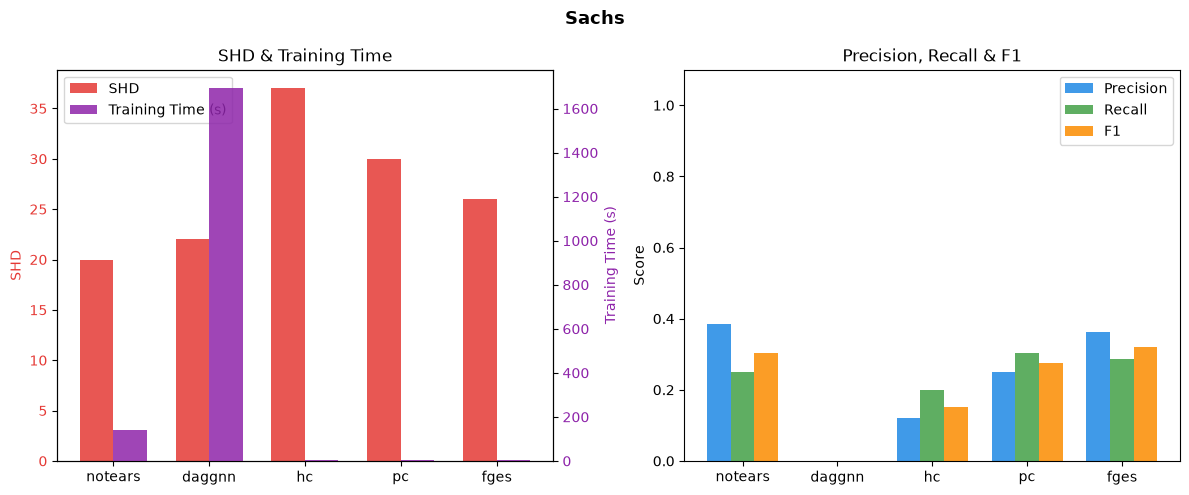

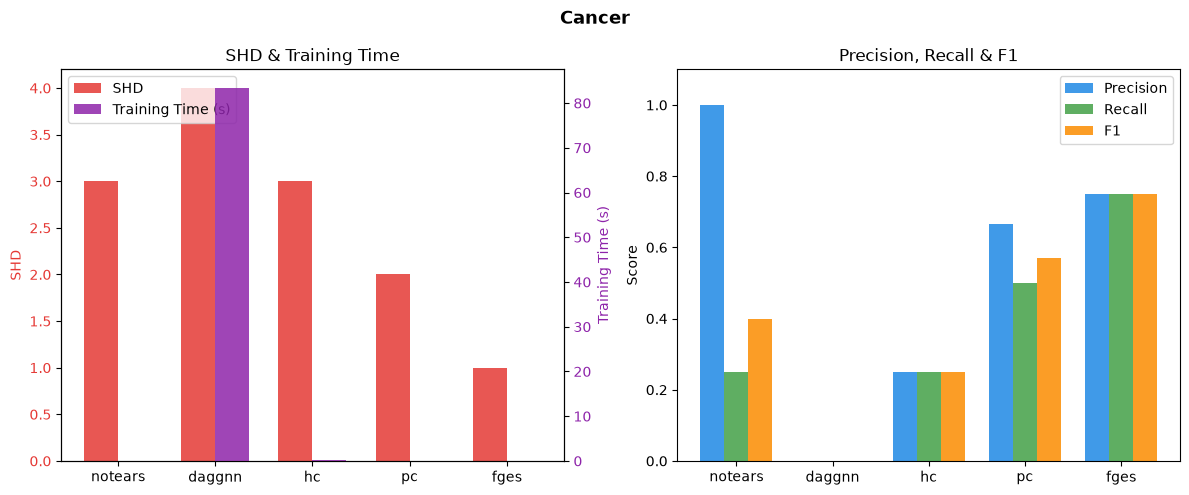

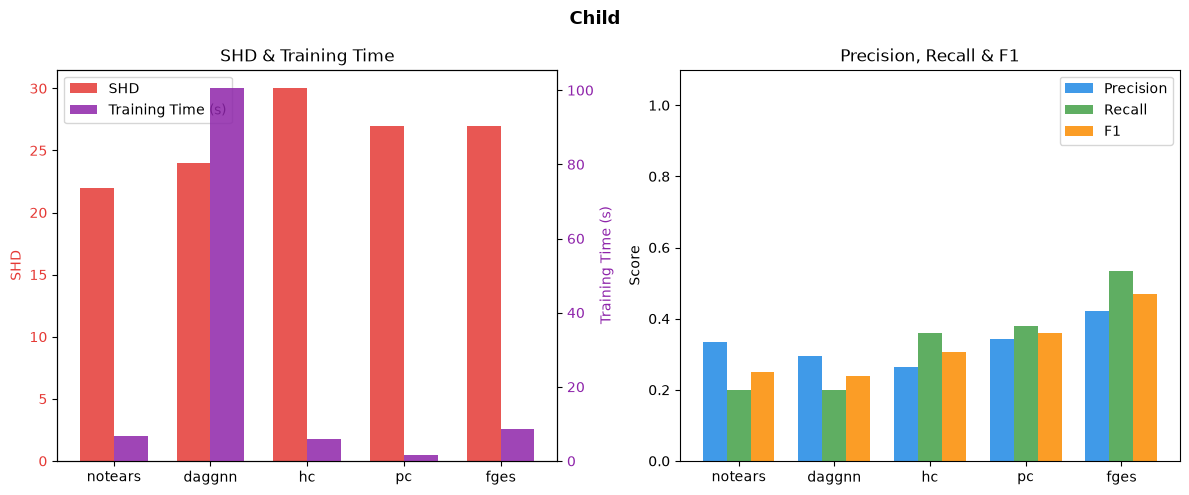

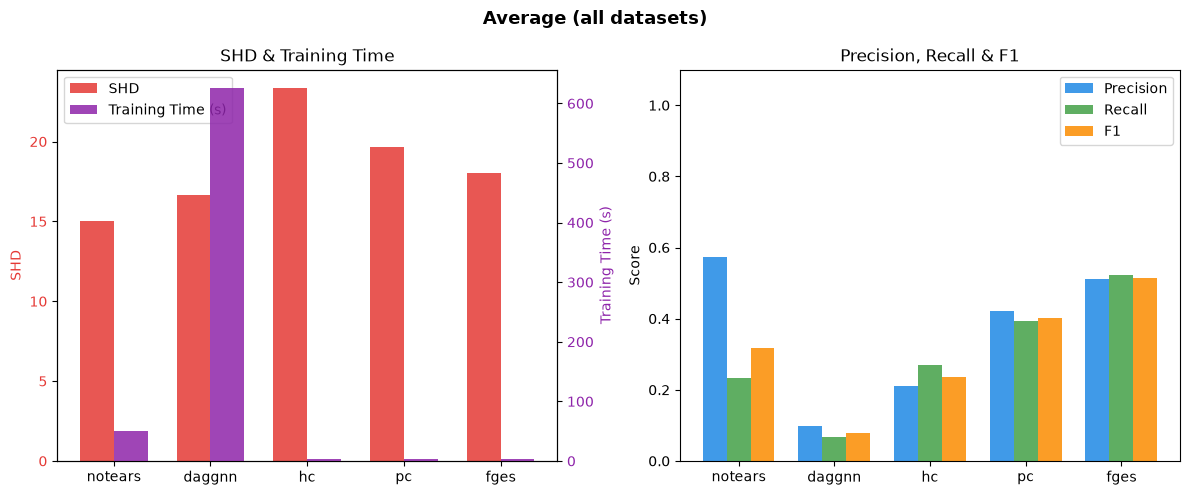

In [7]:
datasets = {
    "Sachs": {
        "notears": (sachs_notears_metrics,  sachs_notears_result.elapsed_s),
        "daggnn":  (sachs_daggnn_metrics,   sachs_daggnn_result.elapsed_s),
        "hc":      (sachs_hc_metrics,       sachs_hc_result.elapsed_s),
        "pc":      (sachs_pc_metrics,       sachs_pc_result.elapsed_s),
        "fges":    (sachs_fges_metrics,     sachs_fges_result.elapsed_s),
    },
    "Cancer": {
        "notears": (cancer_notears_metrics, cancer_notears_result.elapsed_s),
        "daggnn":  (cancer_daggnn_metrics,  cancer_daggnn_result.elapsed_s),
        "hc":      (cancer_hc_metrics,      cancer_hc_result.elapsed_s),
        "pc":      (cancer_pc_metrics,      cancer_pc_result.elapsed_s),
        "fges":    (cancer_fges_metrics,    cancer_fges_result.elapsed_s),
    },
    "Child": {
        "notears": (child_notears_metrics,  child_notears_result.elapsed_s),
        "daggnn":  (child_daggnn_metrics,   child_daggnn_result.elapsed_s),
        "hc":      (child_hc_metrics,       child_hc_result.elapsed_s),
        "pc":      (child_pc_metrics,       child_pc_result.elapsed_s),
        "fges":    (child_fges_metrics,     child_fges_result.elapsed_s),
    },
}

ALGORITHMS  = ["notears", "daggnn", "hc", "pc", "fges"]
SHD_COLOR   = "#E53935"
TIME_COLOR  = "#8E24AA"
PRF_COLORS  = {"precision": "#1E88E5", "recall": "#43A047", "f1": "#FB8C00"}


def _plot_dataset(title, algo_data):
    fig, (ax_shd_time, ax_prf) = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(title, fontsize=13, fontweight="bold")

    x = np.arange(len(ALGORITHMS))
    w = 0.35

    # left: SHD (left axis) + training time (right axis)
    ax_time = ax_shd_time.twinx()

    shd_vals  = [algo_data[a][0]["shd"] for a in ALGORITHMS]
    time_vals = [algo_data[a][1]        for a in ALGORITHMS]

    b_shd  = ax_shd_time.bar(x - w / 2, shd_vals,  w, color=SHD_COLOR,  alpha=0.85, label="SHD")
    b_time = ax_time.bar(    x + w / 2, time_vals, w, color=TIME_COLOR, alpha=0.85, label="Training Time (s)")

    ax_shd_time.set_xticks(x)
    ax_shd_time.set_xticklabels(ALGORITHMS)
    ax_shd_time.set_ylabel("SHD",              color=SHD_COLOR)
    ax_shd_time.tick_params(axis="y",           labelcolor=SHD_COLOR)
    ax_time.set_ylabel("Training Time (s)",     color=TIME_COLOR)
    ax_time.tick_params(axis="y",               labelcolor=TIME_COLOR)
    ax_shd_time.set_title("SHD & Training Time")
    ax_shd_time.legend(handles=[b_shd, b_time], loc="upper left")

    # right: precision, recall, F1 ---
    w3 = 0.25
    offsets = [-w3, 0, w3]
    for (metric, color), offset in zip(PRF_COLORS.items(), offsets):
        vals = [algo_data[a][0][metric] for a in ALGORITHMS]
        ax_prf.bar(x + offset, vals, w3, color=color, alpha=0.85, label=metric.capitalize())

    ax_prf.set_xticks(x)
    ax_prf.set_xticklabels(ALGORITHMS)
    ax_prf.set_ylabel("Score")
    ax_prf.set_ylim(0, 1.1)
    ax_prf.set_title("Precision, Recall & F1")
    ax_prf.legend()

    fig.tight_layout()
    plt.show()


for name, algo_data in datasets.items():
    _plot_dataset(name, algo_data)

# aggregate figure
avg_data = {
    algo: (
        {m: np.mean([datasets[ds][algo][0][m] for ds in datasets])
         for m in ["shd", "precision", "recall", "f1"]},
        np.mean([datasets[ds][algo][1] for ds in datasets]),
    )
    for algo in ALGORITHMS
}
_plot_dataset("Average (all datasets)", avg_data)


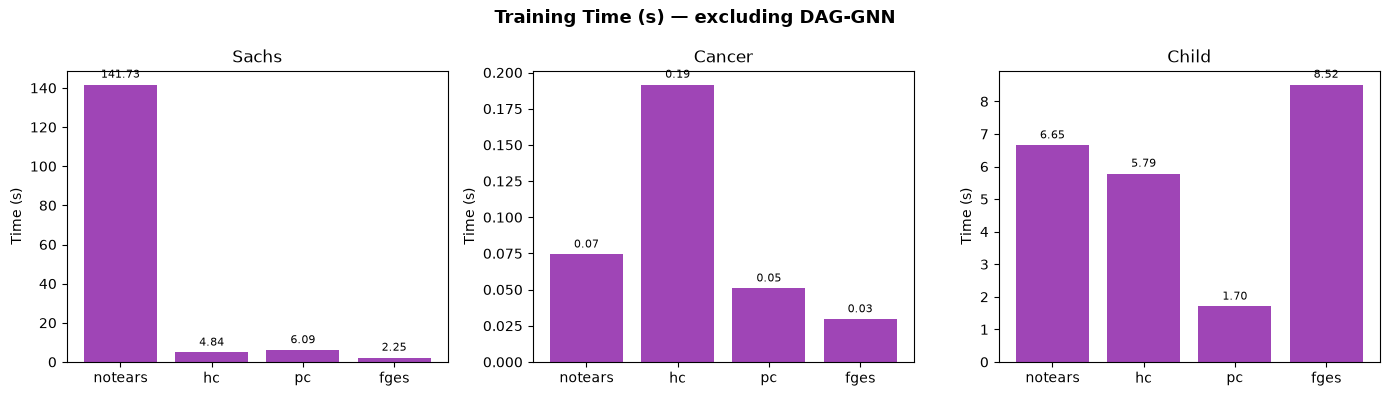

In [17]:
ALGOS_NO_DAGGNN = [a for a in ALGORITHMS if a != "daggnn"]

fig, axes = plt.subplots(1, len(datasets), figsize=(14, 4), sharey=False)
fig.suptitle("Training Time (s) — excluding DAG-GNN", fontsize=13, fontweight="bold")

for ax, (ds_name, algo_data) in zip(axes, datasets.items()):
    x = np.arange(len(ALGOS_NO_DAGGNN))
    times = [algo_data[a][1] for a in ALGOS_NO_DAGGNN]
    bars = ax.bar(x, times, color=TIME_COLOR, alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(ALGOS_NO_DAGGNN)
    ax.set_title(ds_name)
    ax.set_ylabel("Time (s)")
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=8)

fig.tight_layout()
plt.show()
